# What do other aides offer?

**Business question:** How do independent aides in my three cities describe themselves, what do they offer, and what do they charge? Where does my &#36;35 an hour land among them, and what can I say that they do not?

**Why it matters:** Notebook 10 looked at agencies. Notebook 11 looked at what families ask for. This one looks at the people a family is most likely to compare me with: other independent aides. It tells me where my rate sits, which of my services are common, and which are rare.

**Data:** This is not Census data. On October 3, 2026 I read public helper profiles on Care.com for Berkeley, Oakland and Alameda. Each profile is one row in `data/aide_postings.csv`. No names, user names or profile links are recorded, so the page address in each row is the listing page the profile appeared on. `data/aide_postings_sources.csv` shows how many profiles each listing had and how many were read.

**The big caution:** A profile is an advertisement. Many of the "yes" answers come from tick boxes on the site's form, which take one click. So this notebook shows what aides say they offer and what they ask to be paid. It does not show what they really do or what families really pay them.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 90)

aides = pd.read_csv("../data/aide_postings.csv")
sources = pd.read_csv("../data/aide_postings_sources.csv")
family = pd.read_csv("../data/family_postings.csv")   # used once, in section 4

MY_RATE = 35       # dollars an hour
MY_MINIMUM = 4     # hours per visit

# The groups used in this notebook
care = aides[aides["profile_type"] == "senior care"]             # profiles in the senior care section
assistant = aides[aides["profile_type"] != "senior care"]        # assistant and errands profiles
priced = care.dropna(subset=["rate_low"])                        # senior care profiles that show a usable rate

N = len(care)
N_PRICED = len(priced)
print(len(aides), "profiles loaded, all in Berkeley, Oakland or Alameda")
print(f"  {N} senior care profiles ({N_PRICED} show a usable hourly rate)")
print(f"  {len(assistant)} assistant and errands profiles")

139 profiles loaded, all in Berkeley, Oakland or Alameda
  128 senior care profiles (127 show a usable hourly rate)
  11 assistant and errands profiles


## 1. What I read

Care.com has two kinds of listing that matter here: "home care" (senior care helpers) and "personal assistants". Each listing shows a limited number of profiles for a city. I read every profile the site showed. The site fills each city's list with helpers from other cities and, in the assistant listing, with nannies and housekeepers. I skipped those.

In [2]:
for _, r in sources.iterrows():
    line = f"{r['listing']}: read {r['profiles_read']} of the {r['profiles_site_says_exist']} shown, recorded {r['recorded_in_table']}"
    skipped = []
    if r["skipped_other_cities"]:
        skipped.append(f"{r['skipped_other_cities']} in other cities")
    if r["skipped_other_kinds"]:
        skipped.append(f"{r['skipped_other_kinds']} other kinds of helper")
    if r["repeats_on_same_listing"]:
        skipped.append(f"{r['repeats_on_same_listing']} repeats")
    if skipped:
        line += " (skipped " + ", ".join(skipped) + ")"
    print(line)

print(f"\nThe same helper often shows up on more than one listing. After removing repeats: {len(aides)} different profiles.")
print("Senior care profiles by city: " + ", ".join(f"{city} {n}" for city, n in care["city"].value_counts().items()))
print("Assistant profiles by city:   " + ", ".join(f"{city} {n}" for city, n in assistant["city"].value_counts().items()))
print(f"One person has both kinds of profile, so these are {len(aides) - 1} people.")
print("\nThis is every profile the site showed that day. The site may have more helpers than it shows,")
print("so read the counts below as 'of the profiles a family would see', not 'of all aides in the East Bay'.")

Care.com home care, Oakland: read 60 of the 60 shown, recorded 42 (skipped 12 in other cities, 6 repeats)
Care.com home care, Berkeley: read 60 of the 60 shown, recorded 31 (skipped 29 in other cities)
Care.com home care, Alameda: read 60 of the 60 shown, recorded 31 (skipped 29 in other cities)
Care.com personal assistants, Oakland: read 87 of the 87 shown, recorded 65 (skipped 22 other kinds of helper)
Care.com personal assistants, Berkeley: read 60 of the 60 shown, recorded 25 (skipped 16 in other cities, 19 other kinds of helper)
Care.com personal assistants, Alameda: read 60 of the 60 shown, recorded 20 (skipped 27 in other cities, 13 other kinds of helper)

The same helper often shows up on more than one listing. After removing repeats: 139 different profiles.
Senior care profiles by city: Oakland 92, Berkeley 20, Alameda 16
Assistant profiles by city:   Oakland 7, Berkeley 2, Alameda 2
One person has both kinds of profile, so these are 138 people.

This is every profile the site

## 2. What they charge

Each profile shows an hourly rate, either one number or a range such as &#36;25 to &#36;35. The bottom of the range is the starting rate. One profile shows &#36;3 an hour, which looks like a typing mistake, so it is left out of this section.

In [3]:
low, high = priced["rate_low"], priced["rate_high"]
below, at, above = (low < MY_RATE).sum(), (low == MY_RATE).sum(), (low > MY_RATE).sum()

print(f"Starting rate, {N_PRICED} senior care profiles")
print(f"   Lowest ${low.min():.0f}, highest ${low.max():.0f}")
print(f"   Middle profile (the median): ${low.median():.0f}")
print(f"   The middle half start between ${low.quantile(0.25):.0f} and ${low.quantile(0.75):.0f}")
print(f"\nCompared with my ${MY_RATE}:")
print(f"   {below:3d} of {N_PRICED} start below ${MY_RATE}  ({below / N_PRICED:.0%})")
print(f"   {at:3d} of {N_PRICED} start at ${MY_RATE}")
print(f"   {above:3d} of {N_PRICED} start above ${MY_RATE}")

one_number = (low == high).sum()
print(f"\n{one_number} of {N_PRICED} show one number. The other {N_PRICED - one_number} show a range.")
print(f"The top of the range reaches ${MY_RATE} or more in {(high >= MY_RATE).sum()} of {N_PRICED} profiles.")

print("\nMiddle starting rate by city:")
for city, g in priced.groupby("city"):
    print(f"   {city:9s} ${g['rate_low'].median():.0f}   ({len(g)} profiles)")

print(f"\nAssistant and errands profiles ({len(assistant)}): middle starting rate ${assistant['rate_low'].median():.0f}, "
      f"middle top rate ${assistant['rate_high'].median():.0f}.")
print(f"   {(assistant['rate_low'] >= MY_RATE).sum()} of {len(assistant)} start at ${MY_RATE} or more, "
      f"and {(assistant['rate_high'] >= MY_RATE).sum()} of {len(assistant)} reach ${MY_RATE} at the top of their range.")

Starting rate, 127 senior care profiles
   Lowest $17, highest $50
   Middle profile (the median): $28
   The middle half start between $25 and $30

Compared with my $35:
   106 of 127 start below $35  (83%)
     9 of 127 start at $35
    12 of 127 start above $35

89 of 127 show one number. The other 38 show a range.
The top of the range reaches $35 or more in 38 of 127 profiles.

Middle starting rate by city:
   Alameda   $28   (16 profiles)
   Berkeley  $28   (20 profiles)
   Oakland   $28   (91 profiles)

Assistant and errands profiles (11): middle starting rate $30, middle top rate $40.
   4 of 11 start at $35 or more, and 10 of 11 reach $35 at the top of their range.


### Chart: where &#36;35 lands

Each bar is the number of senior care profiles whose starting rate falls in that group. The blue bar is my rate.

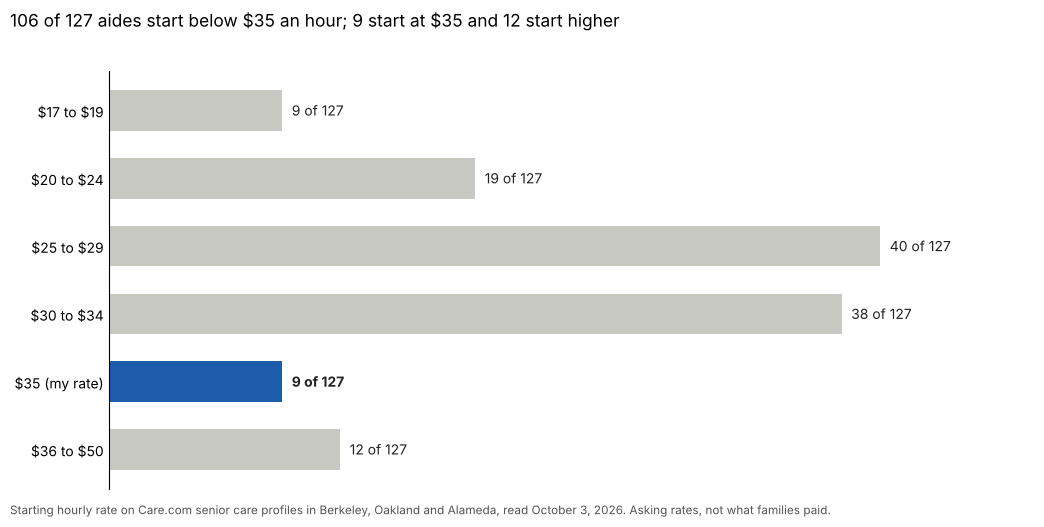

In [4]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)
BLUE, GRAY = "#1c5cab", "#c9c9c4"

GROUPS = [("$17 to $19", 17, 19), ("$20 to $24", 20, 24), ("$25 to $29", 25, 29), ("$30 to $34", 30, 34),
          (f"${MY_RATE} (my rate)", MY_RATE, MY_RATE), ("$36 to $50", 36, 50)]
rates = pd.DataFrame([(name, int(low.between(a, b).sum()), a == MY_RATE) for name, a, b in GROUPS],
                     columns=["starting_rate", "profiles", "my_rate"])
assert rates["profiles"].sum() == N_PRICED      # every profile lands in exactly one group

ypos = list(range(len(rates)))[::-1]   # lowest rate at the top
fig, ax = plt.subplots(figsize=(10.5, 0.55 * len(rates) + 1.9))
ax.barh(ypos, rates["profiles"], color=[BLUE if m else GRAY for m in rates["my_rate"]], height=0.6)
for y, (_, r) in zip(ypos, rates.iterrows()):
    ax.text(r["profiles"] + 0.5, y, f"{r['profiles']} of {N_PRICED}", va="center", fontsize=10, color="#222222",
            fontweight="bold" if r["my_rate"] else "normal")
ax.set_yticks(ypos)
# A dollar sign needs a backslash in chart text, or matplotlib reads it as a math formula
ax.set_yticklabels([name.replace("$", r"\$") for name in rates["starting_rate"]], fontsize=10)
ax.set_xlim(0, rates["profiles"].max() * 1.2)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
fig.suptitle(f"{below} of {N_PRICED} aides start below \\${MY_RATE} an hour; {at} start at \\${MY_RATE} and {above} start higher",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, "Starting hourly rate on Care.com senior care profiles in Berkeley, Oakland and Alameda, read October 3, 2026. "
                     "Asking rates, not what families paid.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
fig.savefig(f"{OUT}/aide_rates.png", dpi=150)
rates.to_csv(f"{OUT}/aide_rates.csv", index=False)
plt.show()

## 3. What they offer

For each profile I recorded "yes" when it lists that kind of help, either in the helper's own words or in the site's tick boxes. "Medical management" is the site's name for one of its tick boxes. I counted it, and any mention of giving or managing medication, as medication help beyond reminders.

In [5]:
OFFERS = {
    "housekeeping":        "Light housekeeping or laundry",
    "meals":               "Meals",
    "personal_care":       "Bathing, dressing or toileting",
    "errands_shopping":    "Errands and shopping",
    "rides":               "Rides for the client (I do not offer this)",
    "medication_more":     "Medication help beyond reminders (I do not offer this)",
    "companionship":       "Companionship",
    "mobility_help":       "Help moving around",
    "spanish":             "Lists Spanish as a language",
    "paperwork_admin":     "Paperwork, bills or appointments",
    "registered":          "Says they are a registered Home Care Aide",
    "tech_help":           "Mentions technology help or tech skills",
}
# Things I can say that could set me apart
MY_EDGE = ["spanish", "paperwork_admin", "registered", "tech_help"]

def offered(df):
    # One True/False column for each thing a profile can say
    out = pd.DataFrame(index=df.index)
    for col in ["housekeeping", "meals", "personal_care", "errands_shopping", "companionship", "mobility_help", "paperwork_admin"]:
        out[col] = df[col].eq("yes")
    out["rides"] = df["drives_clients"].eq("yes")
    out["medication_more"] = df["medication"].eq("medical management or medication help")
    out["spanish"] = df["speaks_spanish"].eq("yes")
    out["registered"] = df["says_registered_home_care_aide"].eq("yes")
    out["tech_help"] = df["mentions_tech"].eq("yes")
    return out[list(OFFERS)]

says = offered(care)
counts = pd.DataFrame({"what": OFFERS, "profiles": says.sum()})
counts["share"] = counts["profiles"] / N
counts["my_edge"] = counts.index.isin(MY_EDGE)
counts = counts.sort_values("profiles", ascending=False)

print(f"What {N} senior care profiles say")
for _, r in counts.iterrows():
    print(f"   {r['profiles']:3d} of {N}  ({r['share']:4.0%})  {r['what']}")

print(f"\nOnly {care['medication'].eq('reminders').sum()} of {N} say medication reminders and nothing more, which is my rule.")

What 128 senior care profiles say
   119 of 128  ( 93%)  Light housekeeping or laundry
   112 of 128  ( 88%)  Meals
   111 of 128  ( 87%)  Bathing, dressing or toileting
   101 of 128  ( 79%)  Errands and shopping
    87 of 128  ( 68%)  Rides for the client (I do not offer this)
    74 of 128  ( 58%)  Medication help beyond reminders (I do not offer this)
    68 of 128  ( 53%)  Companionship
    66 of 128  ( 52%)  Help moving around
    23 of 128  ( 18%)  Lists Spanish as a language
     5 of 128  (  4%)  Paperwork, bills or appointments
     4 of 128  (  3%)  Says they are a registered Home Care Aide
     2 of 128  (  2%)  Mentions technology help or tech skills

Only 4 of 128 say medication reminders and nothing more, which is my rule.


Most profiles offer the same list: housekeeping, meals, hands-on care and errands. About two in three say they drive clients, and more than half tick medication help. The four things at the bottom are the ones I can say that few others do.

## 4. Side by side with what families ask for

This puts the aide profiles next to the 31 local family posts from notebook 11. It shows, for each kind of help, how many families ask and how many aides offer. The two groups are different sizes, so compare the percentages.

In [6]:
local_posts = family[(family["site"] == "Care.com") & (family["category"] == "senior care")
                     & (family["area"] == "Berkeley / Oakland / Alameda")]
N_FAM = len(local_posts)

asks = pd.Series({
    "personal_care":    local_posts["personal_care"].eq("yes").sum(),
    "meals":            local_posts["meals"].eq("yes").sum(),
    "housekeeping":     local_posts["housekeeping"].eq("yes").sum(),
    "mobility_help":    local_posts["mobility_help"].eq("yes").sum(),
    "companionship":    local_posts["companionship"].eq("yes").sum(),
    "errands_shopping": local_posts["errands_shopping"].eq("yes").sum(),
    "rides":            local_posts["drive_client"].eq("yes").sum(),
    "medication_more":  local_posts["medication"].eq("more than reminders").sum(),
    "paperwork_admin":  local_posts["paperwork_admin"].eq("yes").sum(),
    "tech_help":        local_posts["tech_help"].eq("yes").sum(),
    "spanish":          local_posts["language"].str.contains("Spanish").sum(),
})

LABELS = dict(OFFERS, tech_help="Technology help", spanish="Spanish")
compare = pd.DataFrame({"what": [LABELS[k] for k in asks.index], "families_ask": asks.values,
                     "aides_offer": counts.loc[asks.index, "profiles"].values}, index=asks.index)
compare["families_share"] = compare["families_ask"] / N_FAM
compare["aides_share"] = compare["aides_offer"] / N

print(f"{'':58s}{'families ask':>16s}{'aides offer':>18s}")
for _, r in compare.iterrows():
    print(f"{r['what']:58s}{r['families_ask']:4d} of {N_FAM} ({r['families_share']:4.0%}){r['aides_offer']:6d} of {N} ({r['aides_share']:4.0%})")

                                                              families ask       aides offer
Bathing, dressing or toileting                              21 of 31 ( 68%)   111 of 128 ( 87%)
Meals                                                       19 of 31 ( 61%)   112 of 128 ( 88%)
Light housekeeping or laundry                               19 of 31 ( 61%)   119 of 128 ( 93%)
Help moving around                                          19 of 31 ( 61%)    66 of 128 ( 52%)
Companionship                                               17 of 31 ( 55%)    68 of 128 ( 53%)
Errands and shopping                                        13 of 31 ( 42%)   101 of 128 ( 79%)
Rides for the client (I do not offer this)                   9 of 31 ( 29%)    87 of 128 ( 68%)
Medication help beyond reminders (I do not offer this)       5 of 31 ( 16%)    74 of 128 ( 58%)
Paperwork, bills or appointments                             2 of 31 (  6%)     5 of 128 (  4%)
Technology help                            

What this shows:

- Bathing and dressing, meals, housekeeping and errands are offered by more aides than there are families asking. A family that wants those has many aides to pick from.
- Help moving around is the one care task that families ask for more often (61%) than aides list (52%). Companionship is about even.
- The two things I do not offer, rides and medication help beyond reminders, are things most aides say they do. A family that needs those will find someone else easily.
- Paperwork and technology help are rare on both sides of this site. Few families ask and few aides offer. As notebook 11 said, that is partly because of where I looked.
- No local family post asks for Spanish, and about 1 aide in 6 lists it.

## 5. How they try to stand out

These are the things a profile can show besides tasks: training, experience, reviews, languages and rules about hours.

Some terms: a **CNA** is a certified nursing assistant. A **registered Home Care Aide** is someone on California's Home Care Aide Registry, which I am. **IHSS** is In-Home Supportive Services, the county program that pays caregivers for clients with low incomes.

In [7]:
training = care["training_listed"].str.lower()
years = care["years_experience_shown"].dropna()
cond = care["conditions_named"].str.lower()

def line(n, text, of=N):
    print(f"   {n:3d} of {of}  {text}")

print("Trust signals")
line((care["background_check_badge"] == "yes").sum(), "show the site's background check badge (so it sets nobody apart)")
line((care["reviews"] > 0).sum(), "have at least one review")
line((care["hired_by_families"] > 0).sum(), "show that a family on the site hired them at least once")

print("\nTraining listed")
line(training.str.contains("cpr|first aid").sum(), "CPR or first aid")
line(care["training_listed"].str.contains("CNA").sum(), "CNA (one of them is still studying for it)")
line(training.str.contains("home health aide").sum(), "home health aide training or experience")
line((care["training_listed"] == "none listed").sum(), "list no training")

print("\nRegistration")
line((care["says_registered_home_care_aide"] == "yes").sum(), "say they are a registered Home Care Aide")
line((care["says_registered_home_care_aide"] == "not clear").sum(), "say 'registered' without making clear which registry")
line((care["mentions_ihss"] == "yes").sum(), "mention IHSS")

print("\nExperience")
print(f"   {len(years)} of {N} show years of experience. The middle profile shows {years.median():.0f} years, "
      f"and {(years >= 10).sum()} show 10 or more.")

print("\nHealth conditions named")
line(cond.str.contains("dementia|alzheimer|memory").sum(), "name dementia, Alzheimer's or memory care")
line(cond.str.contains("hospice").sum(), "name hospice")
line((care["conditions_named"] == "none named").sum(), "name none")

print("\nLanguages")
line((care["speaks_spanish"] == "yes").sum(), "list Spanish in the site's language field")
line((care["spanish_in_their_own_words"] == "yes").sum(), "say in their own words that they speak Spanish")
other = care[(care["languages"] != "English") & (care["speaks_spanish"] != "yes")]
line(len(other), "list another language besides English (Chinese, French, Vietnamese, Amharic, Tigrinya and others)")

print("\nHours")
line((care["minimum_hours_stated"] != "not stated").sum(), "state a minimum visit or a shift length")
line(care["availability_as_shown"].str.contains("live-in").sum(), "offer live-in care")
line((care["availability_as_shown"] == "not shown").sum(), "show no availability at all")

print(f"\nReady-made wording")
line((care["stock_wording"] == "yes").sum(), "use sentences the site appears to supply, so their bios read alike")

Trust signals
   127 of 128  show the site's background check badge (so it sets nobody apart)
    45 of 128  have at least one review
    23 of 128  show that a family on the site hired them at least once

Training listed
    75 of 128  CPR or first aid
    44 of 128  CNA (one of them is still studying for it)
    32 of 128  home health aide training or experience
     8 of 128  list no training

Registration
     4 of 128  say they are a registered Home Care Aide
     2 of 128  say 'registered' without making clear which registry
     1 of 128  mention IHSS

Experience
   125 of 128 show years of experience. The middle profile shows 7 years, and 58 show 10 or more.

Health conditions named
    74 of 128  name dementia, Alzheimer's or memory care
    36 of 128  name hospice
    48 of 128  name none

Languages
    23 of 128  list Spanish in the site's language field
     5 of 128  say in their own words that they speak Spanish
    13 of 128  list another language besides English (Chines

### What almost nobody says

- **Registered Home Care Aide.** 4 of 128 say it. I am registered, so I can.
- **A minimum visit.** 2 of 128 state one. Families on this site are not used to seeing a minimum.
- **Spanish, in their own words.** 23 list it in the language field, where a family has to look for it. Only 5 say it in the part they wrote themselves.
- **Paperwork or technology help.** 5 and 2 of 128.

## 6. Do the aides who charge &#36;35 or more look different?

This compares the profiles that start at &#36;35 or more with the ones that start lower. The first group is small, so treat this as a hint and not a rule.

In [8]:
top = priced[priced["rate_low"] >= MY_RATE]
rest = priced[priced["rate_low"] < MY_RATE]

def share(df, mask):
    return f"{mask.sum():3d} of {len(df):3d} ({mask.mean():4.0%})"

print(f"{'':44s}{'start at $35 or more':>24s}{'start below $35':>22s}")
print(f"{'Profiles':44s}{len(top):>24d}{len(rest):>22d}")
print(f"{'Middle years of experience shown':44s}{top['years_experience_shown'].median():>24.0f}{rest['years_experience_shown'].median():>22.0f}")
rows = [
    ("Have at least one review",       lambda d: d["reviews"] > 0),
    ("Hired through the site at least once", lambda d: d["hired_by_families"] > 0),
    ("List CNA training",              lambda d: d["training_listed"].str.contains("CNA")),
    ("Offer bathing, dressing or toileting", lambda d: d["personal_care"] == "yes"),
    ("List Spanish",                   lambda d: d["speaks_spanish"] == "yes"),
    ("Use the site's ready-made wording", lambda d: d["stock_wording"] == "yes"),
]
for label, rule in rows:
    print(f"{label:44s}{share(top, rule(top)):>24s}{share(rest, rule(rest)):>22s}")

                                                start at $35 or more       start below $35
Profiles                                                          21                   106
Middle years of experience shown                                  10                     6
Have at least one review                            11 of  21 ( 52%)      34 of 106 ( 32%)
Hired through the site at least once                 5 of  21 ( 24%)      18 of 106 ( 17%)
List CNA training                                    9 of  21 ( 43%)      34 of 106 ( 32%)
Offer bathing, dressing or toileting                20 of  21 ( 95%)      90 of 106 ( 85%)
List Spanish                                         3 of  21 ( 14%)      20 of 106 ( 19%)
Use the site's ready-made wording                    7 of  21 ( 33%)      41 of 106 ( 39%)


The higher-priced aides show more years of experience and are more likely to have a review. Listing Spanish does not go with a higher rate here.

## 7. Who is closest to my offer?

My offer is hands-on care, plus paperwork and technology help, in English and Spanish. This cell looks for profiles that combine those.

In [9]:
hands_on = care["personal_care"] == "yes"
paper_or_tech = (care["paperwork_admin"] == "yes") | (care["mentions_tech"] == "yes")
spanish = care["speaks_spanish"] == "yes"

def show(df):
    for _, r in df.iterrows():
        rate = f"${r['rate_low']:.0f}" if r["rate_low"] == r["rate_high"] else f"${r['rate_low']:.0f} to ${r['rate_high']:.0f}"
        extras = [name for name, col in [("paperwork", "paperwork_admin"), ("technology", "mentions_tech")] if r[col] == "yes"]
        if r["speaks_spanish"] == "yes":
            extras.append("Spanish")
        if r["says_registered_home_care_aide"] == "yes":
            extras.append("says registered")
        print(f"   {r['profile_id']}  {r['city']}, {rate}: {', '.join(extras)}")
        print(f"         \"{r['their_words']}\"")

print(f"Hands-on care plus paperwork or technology help: {(hands_on & paper_or_tech).sum()} of {N}")
show(care[hands_on & paper_or_tech])

print(f"\nPaperwork or technology help without hands-on care: {(~hands_on & paper_or_tech).sum()} of {N}")
show(care[~hands_on & paper_or_tech])

print(f"\nHands-on care plus Spanish: {(hands_on & spanish).sum()} of {N}")
print(f"Hands-on care, plus paperwork or technology help, plus Spanish: {(hands_on & paper_or_tech & spanish).sum()} of {N}")

print(f"\nAssistant and errands profiles ({len(assistant)}):")
print(f"   {(assistant['paperwork_admin'] == 'yes').sum()} offer paperwork or admin help, "
      f"{(assistant['mentions_tech'] == 'yes').sum()} mention technology, "
      f"{(assistant['personal_care'] == 'yes').sum()} offers hands-on care, "
      f"{(assistant['speaks_spanish'] == 'yes').sum()} list Spanish.")
print("   Most are household managers, organizers or errand runners for busy families, not for older adults.")

Hands-on care plus paperwork or technology help: 3 of 128
   A019  Oakland, $30: paperwork, says registered
         "financial organization, bill management, and contractor oversight"
   A044  Oakland, $30: paperwork
         "mature, compassionate, appreciative, and good-natured"
   A045  Oakland, $20 to $50: paperwork, says registered
         "Familiar with scheduling and managing appointments, coordinating household support"

Paperwork or technology help without hands-on care: 3 of 128
   A048  Oakland, $30 to $40: paperwork, Spanish
         "Personal assistant tasks as well as home care"
   A049  Oakland, $30 to $45: paperwork, technology
         "admin works (booking tickets, planning trips, paperwork helps, and making appointments)"
   A086  Oakland, $30: technology
         "technology assistance, pet care, and respite for family caregivers"

Hands-on care plus Spanish: 21 of 128
Hands-on care, plus paperwork or technology help, plus Spanish: 0 of 128

Assistant and errands 

Nobody in these 139 profiles offers my whole combination. Three aides pair hands-on care with paperwork help, and none of those three lists Spanish. The aides who mention technology do not do hands-on care.

## 8. The words aides use

One short phrase from each profile, exactly as written. This counts how often some common words appear in those phrases. I picked one phrase per profile by hand, so this is a rough guide only.

49 of the 128 profiles use sentences that the site appears to supply, so the count is split in two: profiles written in the helper's own words, and profiles built from the ready-made sentences.

In [10]:
phrases = care["their_words"].str.lower()
WORDS = {
    "compassionate / compassion": r"compassion",
    "patient / patience":         r"\bpatien",
    "calm":                       r"\bcalm",
    "reliable":                   r"\breliab",
    "experience / experienced":   r"\bexperience",
    "caring":                     r"\bcaring",
    "dependable":                 r"\bdependab",
    "passion / passionate":       r"\bpassion",
    "kind":                       r"\bkind\b",
    "trustworthy / trust":        r"\btrust",
    "bilingual":                  r"\bbilingual",
    "organized":                  r"\borganiz",
}
own = care[care["stock_wording"] == "no"]        # written in the helper's own words
ready = care[care["stock_wording"] == "yes"]     # built from the site's ready-made sentences
words = pd.DataFrame({
    "own_words": {w: int(phrases[own.index].str.contains(p).sum()) for w, p in WORDS.items()},
    "ready_made": {w: int(phrases[ready.index].str.contains(p).sum()) for w, p in WORDS.items()},
})
words["all"] = words["own_words"] + words["ready_made"]
words = words.sort_values(["own_words", "all"], ascending=False)

print(f"Profiles whose phrase uses the word")
print(f"{'':30s}{'own words':>12s}{'ready-made':>14s}")
print(f"{'':30s}{'(of ' + str(len(own)) + ')':>12s}{'(of ' + str(len(ready)) + ')':>14s}")
for w, r in words.iterrows():
    print(f"   {w:27s}{r['own_words']:>12d}{r['ready_made']:>14d}")

print(f"\nA sample of phrases from the {len(own)} profiles written in the helper's own words:")
for _, r in own.sample(18, random_state=3).sort_values("profile_id").iterrows():
    print(f"   {r['city']:9s} \"{r['their_words']}\"")

Profiles whose phrase uses the word
                                 own words    ready-made
                                   (of 79)       (of 49)
   compassionate / compassion           22            13
   reliable                             10             1
   caring                                9             0
   patient / patience                    8            29
   experience / experienced              7             3
   dependable                            7             0
   kind                                  5             0
   passion / passionate                  3             2
   trustworthy / trust                   3             0
   organized                             3             0
   bilingual                             2             0
   calm                                  1            25

A sample of phrases from the 79 profiles written in the helper's own words:
   Oakland   "I feel like I take care my own parents or grandparents"
   Oakland   "I pro

When aides write their own words, "compassionate" is the word they pick most, then "reliable". "Patient" and "calm" come mostly from the site's ready-made sentences. Words about what an aide actually does for a client, such as "organized" or "bilingual", are rare.

## 9. Chart: what aide profiles say

Each bar is the number of senior care profiles that say that thing. Blue bars are things I can say that few other aides do.

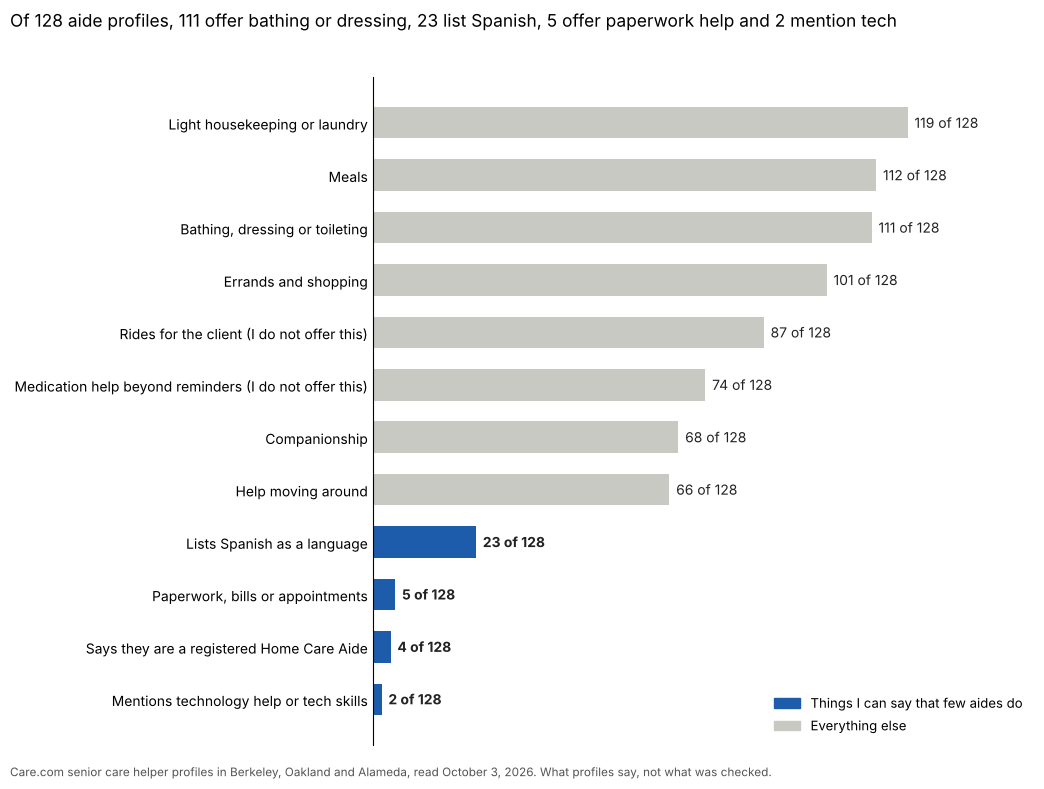

In [11]:
ypos = list(range(len(counts)))[::-1]   # first row at the top

fig, ax = plt.subplots(figsize=(10.5, 0.5 * len(counts) + 1.9))
ax.barh(ypos, counts["profiles"], color=[BLUE if e else GRAY for e in counts["my_edge"]], height=0.6)
for y, (_, r) in zip(ypos, counts.iterrows()):
    ax.text(r["profiles"] + 1.5, y, f"{r['profiles']} of {N}", va="center", fontsize=10, color="#222222",
            fontweight="bold" if r["my_edge"] else "normal")
ax.set_yticks(ypos)
ax.set_yticklabels(counts["what"], fontsize=10)
ax.set_xlim(0, N * 1.15)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=GRAY)]
ax.legend(handles, ["Things I can say that few aides do", "Everything else"],
          loc="lower right", frameon=False, fontsize=9.5)
c = counts["profiles"]
fig.suptitle(f"Of {N} aide profiles, {c['personal_care']} offer bathing or dressing, {c['spanish']} list Spanish, "
             f"{c['paperwork_admin']} offer paperwork help and {c['tech_help']} mention tech",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, "Care.com senior care helper profiles in Berkeley, Oakland and Alameda, read October 3, 2026. "
                     "What profiles say, not what was checked.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
fig.savefig(f"{OUT}/what_aides_offer.png", dpi=150)
counts.assign(share=counts["share"].round(3)).to_csv(f"{OUT}/what_aides_offer.csv")
compare.assign(families_share=compare["families_share"].round(3),
               aides_share=compare["aides_share"].round(3)).to_csv(f"{OUT}/families_ask_vs_aides_offer.csv")
plt.show()

## 10. What I decided

These are decisions I had already made, checked against what other aides advertise.

- **Lead with hands-on care plus paperwork and technology help?** Yes. It is still rare. 3 of 128 profiles pair hands-on care with paperwork help, 2 mention technology, and nobody offers the whole combination with Spanish.
- **Lead with being bilingual in English and Spanish?** Yes, but it is less rare than notebook 10 suggested. 23 of 128 list Spanish. Notebook 10 read only the short listing text, where it does not show. Only 5 say it in their own words, so saying it plainly still stands out.
- **Keep &#36;35 an hour?** Yes, as decided in notebook 05. It is above the starting rate of 106 of 127 aides (83%). The middle aide starts at &#36;28.
- **Keep the 4-hour minimum?** Yes, as decided in notebook 05. Only 2 of 128 state any minimum, so mine will be new to families who shop on this site.
- **Keep the rule that I do not drive clients?** Yes. 87 of 128 say they drive clients, so this is one place where most aides offer more than I do.
- **Keep medication reminders only?** Yes. 74 of 128 tick medication help. Only 4 say reminders and nothing more.

### Still open

- **How do I back up a rate above most aides?** The ones who start at &#36;35 or more show more years of experience and more reviews.
- **Do I say "registered Home Care Aide" at the top of my own wording?** Only 4 of 128 do.
- **How do I word the 4-hour minimum and the no-driving rule?** Almost no profile states a minimum, and most say they drive.
- **Which words do I use?** "Compassionate" is the word aides pick most. "Patient" and "calm" come mostly from the site's ready-made sentences. Notebook 11 found families ask for "patient" and "reliable".

### Limits to remember
- This is one site on one day. Aides who find clients by word of mouth, through an agency, through IHSS or on neighborhood sites do not appear here.
- The site shows a limited number of profiles for each city, so this is what a family would see, not every aide.
- A "yes" means the profile says so. Tick boxes take one click, and nobody checked the claims.
- The rate is an asking rate. It is not what families paid.
- Oakland has 92 of the 128 profiles. Berkeley (20) and Alameda (16) are too few to compare cities closely.
- I read the profiles through a page-reading tool and recorded them by hand. I re-checked 15 key profiles, but a judgment call on one profile can move a count by one.
- No names or profile links are kept, so a single row cannot be traced back to a person. The listing page is the source.